# 🛒 LỚP 3: KHAI PHÁ LUẬT KẾT HỢP (ASSOCIATION RULES) 

**Mục tiêu kinh doanh:** Khám phá các mẫu "Giỏ hàng bị hoàn trả". Có những nhóm mặt hàng nào (Category) mà khi khách hàng mua chung với nhau thì xác suất họ trả lại cả hai (hoặc một trong hai) tăng vọt không?

**Vai trò trong Pipeline:**
- **Lớp 1 (Clustering):** Tìm ra **AI** là người hay trả hàng (Nhóm High Returners).
- **Lớp 2 (Classification):** Tìm ra **TẠI SAO** hàng bị trả (Giá cao, Thương hiệu).
- **Lớp 3 (Association Rules):** Tìm ra **CÁI GÌ** hay bị trả cùng nhau (Sự kết hợp sản phẩm lỗi/không tương thích).

---
### Quy trình triển khai
1. **Load Data:** Lọc toàn bộ các đơn hàng (`order_id`) có chứa trạng thái `Returned`. Gom nhóm các danh mục (`category`) bị trả trong cùng 1 đơn hàng thành một "Basket" (Giỏ).
2. **Transaction Encoding:** Biến đổi danh sách giỏ hàng thành ma trận nhị phân (One-Hot) để thuật toán hiểu.
3. **Apriori Algorithm:** Tìm các tập hợp sản phẩm (Itemsets) thường xuyên xuất hiện cùng nhau.
4. **Rút trích Luật (Association Rules):** Tính toán các chỉ số *Support*, *Confidence*, và *Lift*.
5. **Trực quan hóa:** Vẽ biểu đồ Scatter Plot (Support vs Confidence) và diễn giải các quy tắc quan trọng nhất.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

from database import query_db
print("✅ Đã tải xong thư viện.")

✅ Đã tải xong thư viện.


## 1. Truy xuất dữ liệu Giỏ hàng bị trả
Lấy danh sách các `category` thuộc cùng một `order_id` mà trạng thái là 'Returned'.

In [2]:
query = """
SELECT 
    oi.order_id,
    p.category
FROM order_items oi
JOIN products p ON oi.product_id = p.id
WHERE oi.status = 'Returned'
"""

print("⏳ Đang tải dữ liệu từ database...")
df = query_db(query)

if df is not None:
    print(f"✅ Tổng số mặt hàng bị trả: {len(df):,}")
    display(df.head())

⏳ Đang tải dữ liệu từ database...
✅ Tổng số mặt hàng bị trả: 18,187


,order_id,category
0,1103,Accessories
1,108423,Accessories
2,59748,Plus
3,64339,Accessories
4,72038,Accessories


## 2. Tiền xử lý (Transaction Encoding)
Biến bảng dữ liệu dọc thành danh sách các giỏ (basket). Mỗi giỏ chứa các danh mục quần áo bị trả lại.

In [3]:
if df is not None:
    # Gom nhóm các danh mục bị trả theo từng mã đơn hàng (order_id)
    # Dùng set() để loại bỏ các danh mục trùng lặp trong cùng 1 đơn (VD: trả 2 cái áo thun thì chỉ tính là 'Áo thun')
    transactions_df = df.groupby('order_id')['category'].apply(lambda x: list(set(x))).reset_index()
    transactions = transactions_df['category'].tolist()
    
    # Lọc bỏ các đơn hàng chỉ trả 1 món (Vì luật kết hợp cần ít nhất 2 món)
    transactions = [t for t in transactions if len(t) > 1]
    
    print(f"✅ Số lượng giỏ hàng bị trả CÓ TỪ 2 MÓN TRỞ LÊN: {len(transactions):,}")
    print("Mẫu 5 giỏ hàng đầu tiên:")
    for i, t in enumerate(transactions[:5]):
        print(f"  Giỏ {i+1}: {t}")
        
    # Chuyển đổi thành ma trận nhị phân (Mỗi cột là 1 danh mục, 1 là có, 0 là không)
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    encoded_df = pd.DataFrame(te_ary, columns=te.columns_)
    
    print(f"Kích thước ma trận giao dịch (Số đơn x Số danh mục): {encoded_df.shape}")

✅ Số lượng giỏ hàng bị trả CÓ TỪ 2 MÓN TRỞ LÊN: 3,608
Mẫu 5 giỏ hàng đầu tiên:
  Giỏ 1: ['Pants', 'Sleep & Lounge']
  Giỏ 2: ['Skirts', 'Accessories']
  Giỏ 3: ['Tops & Tees', 'Fashion Hoodies & Sweatshirts', 'Jeans']
  Giỏ 4: ['Socks', 'Swim']
  Giỏ 5: ['Blazers & Jackets', 'Active']
Kích thước ma trận giao dịch (Số đơn x Số danh mục): (3608, 26)


## 3. Áp dụng Thuật toán Apriori
Tìm các tổ hợp danh mục xuất hiện đủ nhiều (Tối thiểu 0.5% số đơn hàng bị trả nhiều món).

In [4]:
if df is not None:
    # Tìm Frequent Itemsets với min_support = 0.005 (0.5%)
    # Support nhỏ vì tỷ lệ một đơn hàng mua và trả trùng khớp 2 danh mục cụ thể là rất hiếm.
    frequent_itemsets = apriori(encoded_df, min_support=0.005, use_colnames=True)
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
    
    print(f"✅ Tìm thấy {len(frequent_itemsets)} tập hợp phổ biến (Frequent Itemsets).")
    display(frequent_itemsets.sort_values(by='support', ascending=False).head(10))

✅ Tìm thấy 163 tập hợp phổ biến (Frequent Itemsets).


,support,itemsets,length
6,0.172949,(Jeans),1
5,0.163248,(Intimates),1
4,0.161585,(Fashion Hoodies & Sweatshirts),1
14,0.154933,(Shorts),1
22,0.154933,(Swim),1
23,0.152993,(Tops & Tees),1
21,0.141353,(Sweaters),1
16,0.138858,(Sleep & Lounge),1
0,0.134424,(Accessories),1
10,0.123614,(Outerwear & Coats),1


## 4. Rút trích Luật Kết Hợp (Association Rules)
Lọc ra các luật thực sự có ý nghĩa dựa trên chỉ số **LIFT**.
- **Lift > 1**: Hai món này có quan hệ "kéo nhau" đi xuống (thường bị trả chung).
- **Confidence**: Khi món A bị trả, xác suất món B bị trả cùng là bao nhiêu?

In [5]:
if df is not None:
    if not frequent_itemsets.empty:
        # Rút trích quy tắc dựa trên Lift > 1.0 (Có tương quan dương)
        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
        
        # Làm gọn hiển thị: chuyển đổi frozenset thành chuỗi
        rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
        
        # Sắp xếp theo LIFT (độ mạnh của quy tắc) và CONFIDENCE (độ tin cậy)
        rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False]).reset_index(drop=True)
        
        print(f"✅ Tìm thấy {len(rules)} luật kết hợp có ý nghĩa (Lift > 1).")
        print("📌 TOP 10 LUẬT BỊ TRẢ HÀNG MẠNH NHẤT:")
        
        display_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)
        display(display_rules)
    else:
        print("❌ Không tìm thấy tập phổ biến nào. Hãy thử giảm min_support.")

✅ Tìm thấy 44 luật kết hợp có ý nghĩa (Lift > 1).
📌 TOP 10 LUẬT BỊ TRẢ HÀNG MẠNH NHẤT:


,antecedents,consequents,support,confidence,lift
0,Maternity,Dresses,0.008315,0.131004,1.883123
1,Dresses,Maternity,0.008315,0.119522,1.883123
2,Leggings,Intimates,0.013027,0.291925,1.788229
3,Intimates,Leggings,0.013027,0.079796,1.788229
4,Plus,Dresses,0.007483,0.123853,1.780328
5,Dresses,Plus,0.007483,0.107570,1.780328
6,Maternity,Intimates,0.018016,0.283843,1.738718
7,Intimates,Maternity,0.018016,0.110357,1.738718
8,Intimates,Socks & Hosiery,0.013581,0.083192,1.667534
9,Socks & Hosiery,Intimates,0.013581,0.272222,1.667534


### Trực quan hóa các Quy tắc (Scatter Plot)
Biểu đồ này giúp phân tích tổng quan các luật tìm được. Các điểm nằm ở **góc phải trên cùng, có màu đậm** là những luật Vàng (Vừa có Support cao, vừa có Confidence cao, vừa có LIFT mạnh).

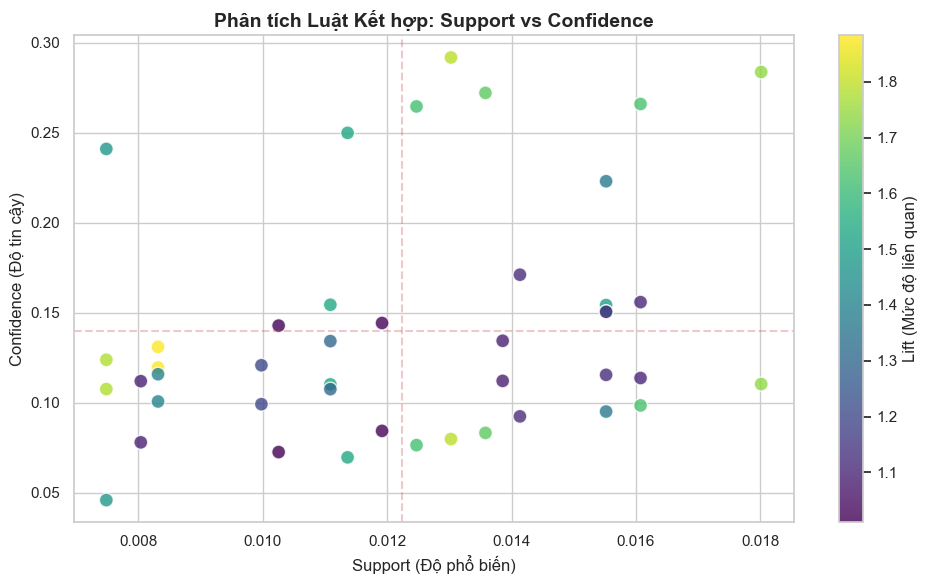

In [6]:
if df is not None and not rules.empty:
    plt.figure(figsize=(10, 6))
    
    # Vẽ scatter plot: X = Support, Y = Confidence, Màu sắc = Lift
    sc = plt.scatter(rules['support'], rules['confidence'], 
                     c=rules['lift'], cmap='viridis', 
                     alpha=0.8, edgecolors='w', s=100)
    
    plt.colorbar(sc, label='Lift (Mức độ liên quan)')
    plt.title('Phân tích Luật Kết hợp: Support vs Confidence', fontsize=14, fontweight='bold')
    plt.xlabel('Support (Độ phổ biến)')
    plt.ylabel('Confidence (Độ tin cậy)')
    
    # Thêm đường viền mờ cho các vùng quy tắc mạnh
    plt.axhline(y=rules['confidence'].mean(), color='r', linestyle='--', alpha=0.3)
    plt.axvline(x=rules['support'].mean(), color='r', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 5. Phân tích Nghiệp vụ (Business Recommendations)

Nếu bạn quan sát bảng Top 10 luật và biểu đồ, bạn sẽ thấy những "combo" nào thường "chết chùm" với nhau (VD: Khách hàng mua *Jeans* và *Tops & Tees* rồi trả lại cả 2).

**Hành động đề xuất (Actionable Insights):**
1. **Sửa đổi Thuật toán Gợi ý (Cross-sell/Up-sell):** Tuyệt đối KHÔNG gợi ý combo sản phẩm X và Y đi kèm với nhau nếu chúng có LIFT trả hàng quá cao. Khuyến mãi combo này chỉ làm tăng chi phí vận chuyển hoàn trả.
2. **Kiểm tra Quy trình Đóng gói:** Nếu hai món hay bị trả chung, có thể do kho hàng đóng gói sai kích thước hoặc chúng dễ làm hỏng nhau trong quá trình vận chuyển (ví dụ: quần áo mix với giày dép dễ bị xước/nhăn).
3. **Phân tích Xu hướng:** Kiểm tra xem combo này có phải là một "Hot trend" trên Tiktok/Instagram khiến khách hàng mua bốc đồng mặc thử rồi hoàn trả ngay hay không (Wardrobing fraud).